# SIT796 Reinforcement Learning
## Distinction Task 10.2   Literature Review & Summarisation

**Survey:** Kaufmann, Weng, Bengs & Hüllermeier (2025).  
*A Survey of Reinforcement Learning from Human Feedback.* arXiv:2312.14925v3


In [1]:
# Imports
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
from collections import defaultdict
import random, textwrap, warnings
warnings.filterwarnings('ignore')

np.random.seed(42); random.seed(42)
plt.rcParams.update({
    'figure.dpi': 120, 'axes.spines.top': False, 'axes.spines.right': False,
    'font.family': 'DejaVu Sans', 'axes.titlesize': 11,
})


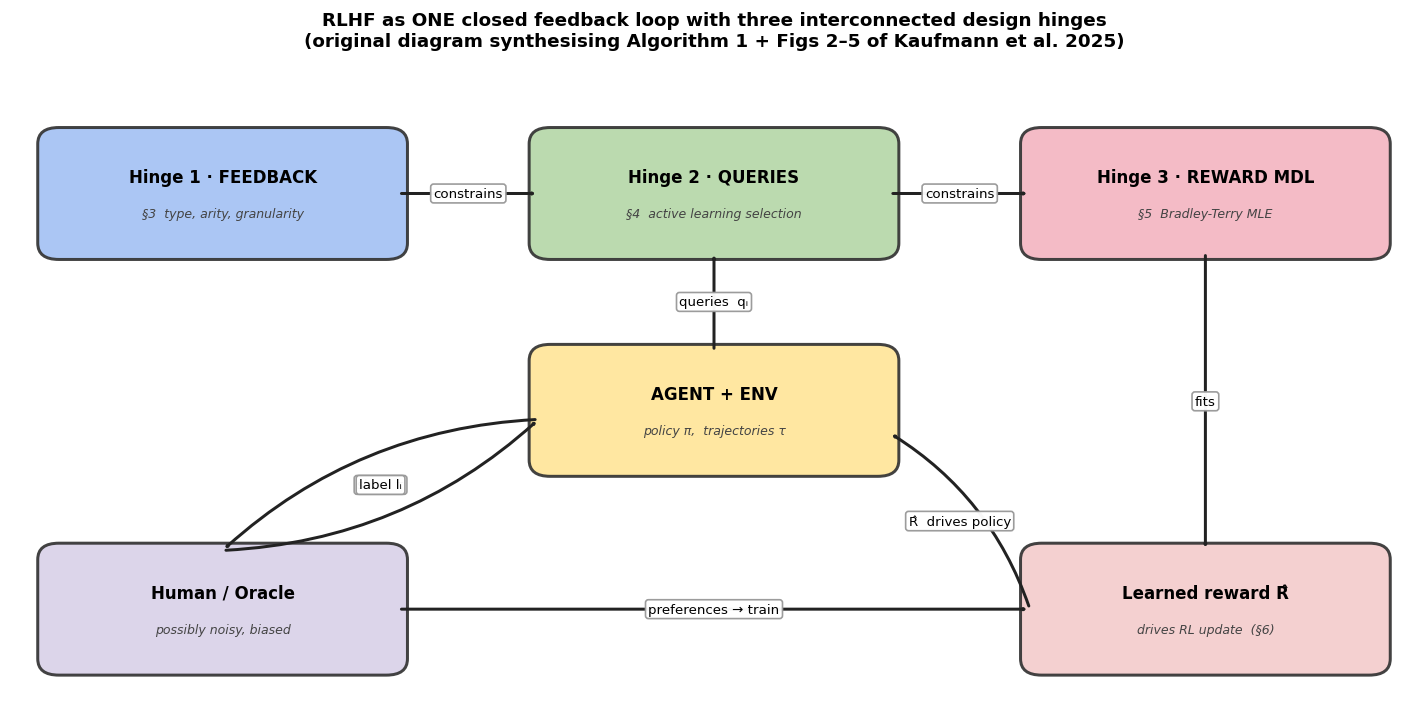

Figure 1 saved.


In [2]:
# Figure 1: RLHF as one closed loop
fig, ax = plt.subplots(figsize=(12, 6))
ax.set_xlim(0, 12); ax.set_ylim(0, 7); ax.axis('off')

def box(x, y, w, h, title, sub, col):
    p = FancyBboxPatch((x, y), w, h,
        boxstyle="round,pad=0.08,rounding_size=0.18",
        lw=1.8, edgecolor='#333', facecolor=col, alpha=0.92, zorder=2)
    ax.add_patch(p)
    ax.text(x+w/2, y+h/2+.18, title, ha='center', va='center',
            fontsize=10, fontweight='bold', zorder=3)
    ax.text(x+w/2, y+h/2-.22, sub, ha='center', va='center',
            fontsize=7.5, style='italic', color='#444', zorder=3)

def arr(x1,y1,x2,y2, lbl=None, curve=0, col='#222'):
    p = FancyArrowPatch((x1,y1),(x2,y2),
        connectionstyle=f"arc3,rad={curve}",
        arrowstyle='->,head_width=0.38,head_length=0.55',
        lw=1.8, color=col, zorder=4)
    ax.add_patch(p)
    if lbl:
        mx=(x1+x2)/2; my=(y1+y2)/2
        ax.text(mx, my, lbl, ha='center', va='center', fontsize=8,
            bbox=dict(boxstyle='round,pad=0.22', fc='white', ec='#999', alpha=.97), zorder=5)

# nodes
box(0.3, 4.9, 3.0, 1.3, 'Hinge 1 · FEEDBACK',  '§3  type, arity, granularity',   '#A4C2F4')
box(4.5, 4.9, 3.0, 1.3, 'Hinge 2 · QUERIES',    '§4  active learning selection',  '#B6D7A8')
box(8.7, 4.9, 3.0, 1.3, 'Hinge 3 · REWARD MDL', '§5  Bradley-Terry MLE',          '#F4B6C2')
box(4.5, 2.5, 3.0, 1.3, 'AGENT + ENV',           'policy π,  trajectories τ',      '#FFE599')
box(0.3, 0.3, 3.0, 1.3, 'Human / Oracle',         'possibly noisy, biased',         '#D9D2E9')
box(8.7, 0.3, 3.0, 1.3, 'Learned reward R̂',      'drives RL update  (§6)',         '#F4CCCC')

# arrows
arr(3.3, 5.55, 4.5, 5.55, 'constrains')
arr(7.5, 5.55, 8.7, 5.55, 'constrains')
arr(6.0, 3.8,  6.0, 4.9,  'queries  qᵢ')
arr(4.5, 3.05, 1.8, 1.6,  'show τ',   curve=0.18)
arr(1.8, 1.6,  4.5, 3.05, 'label lᵢ', curve=0.18)
arr(3.3, 0.95, 8.7, 0.95, 'preferences → train')
arr(10.2,4.9, 10.2,1.6,   'fits',     curve=0)
arr(8.7, 0.95, 7.5, 2.9,  'R̂  drives policy', curve=0.18)

ax.set_title("RLHF as ONE closed feedback loop with three interconnected design hinges\n"
             "(original diagram synthesising Algorithm 1 + Figs 2–5 of Kaufmann et al. 2025)",
             fontsize=11, fontweight='bold', pad=10)
plt.tight_layout()
plt.savefig('fig1_loop.png', dpi=140, bbox_inches='tight', facecolor='white')
plt.show()
print("Figure 1 saved.")

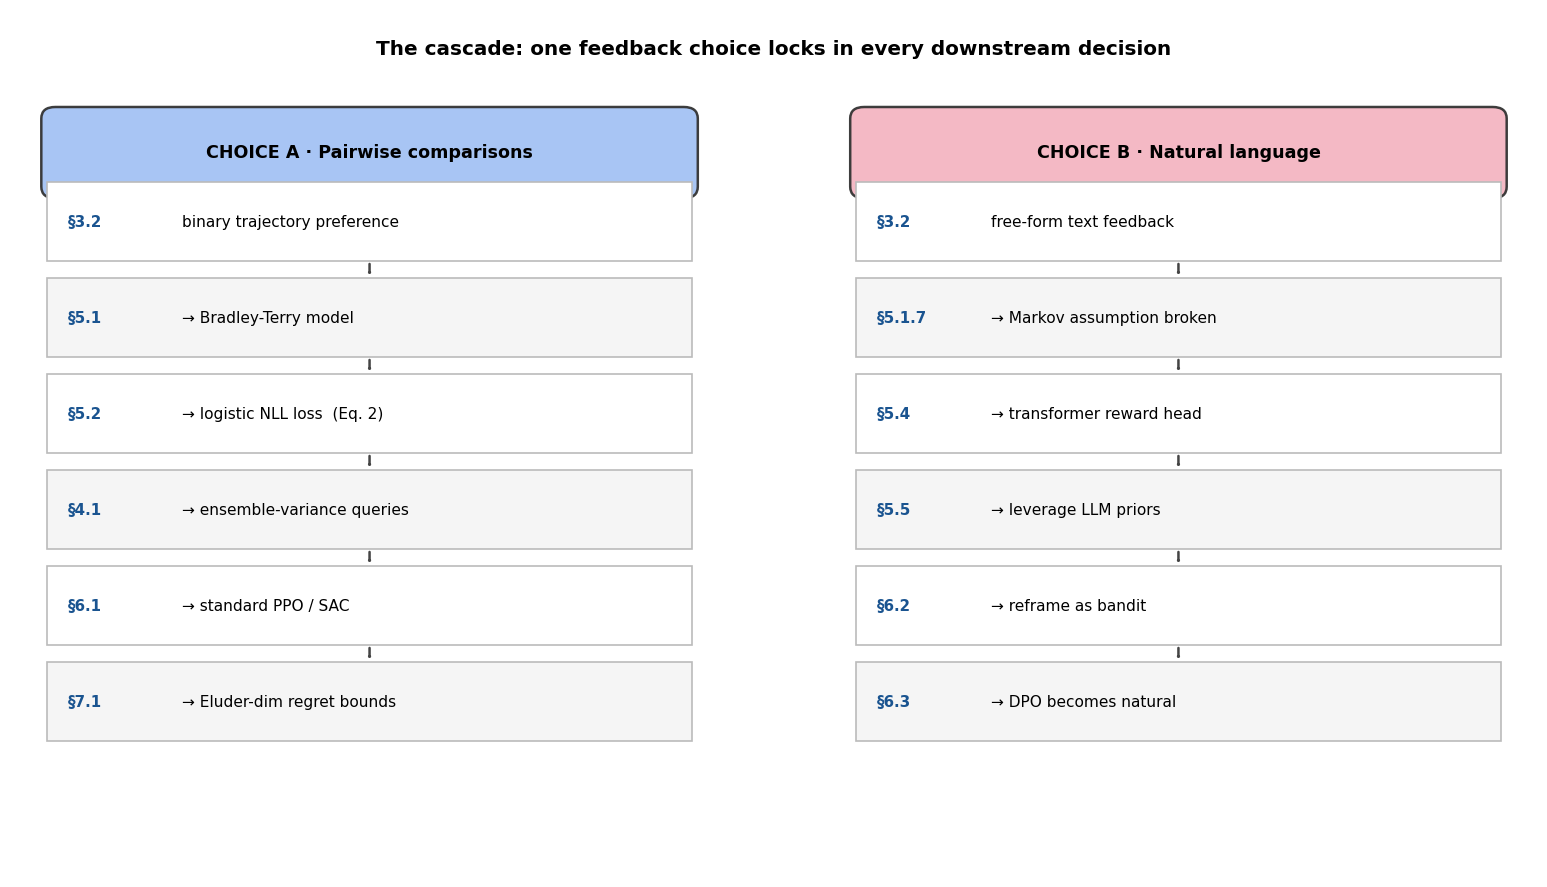

Figure 2 saved.


In [3]:
# Figure 2: the domino effect
fig, ax = plt.subplots(figsize=(13, 7.5))
ax.set_xlim(0,13); ax.set_ylim(0,9); ax.axis('off')

def col_blocks(ox, header, rows, hdr_col):
    p = FancyBboxPatch((ox,7.1),5.5,.85,
        boxstyle="round,pad=0.05,rounding_size=0.12",
        lw=1.5,ec='#333',fc=hdr_col,alpha=.95,zorder=2)
    ax.add_patch(p)
    ax.text(ox+2.75,7.53,header,ha='center',va='center',
            fontsize=10.5,fontweight='bold',zorder=3)
    y=6.4; h=0.82
    for i,(sec,txt) in enumerate(rows):
        fc='#fff' if i%2==0 else '#f5f5f5'
        r=mpatches.Rectangle((ox,y),5.5,h,lw=1,ec='#bbb',fc=fc,zorder=2)
        ax.add_patch(r)
        ax.text(ox+.18,y+h/2, sec, fontsize=9, fontweight='bold',
                va='center',color='#1A5490',zorder=3)
        ax.text(ox+1.15,y+h/2, txt, fontsize=9.2, va='center',zorder=3)
        if i<len(rows)-1:
            a=FancyArrowPatch((ox+2.75,y),(ox+2.75,y-.18),
                arrowstyle='->,head_width=0.26,head_length=0.28',
                lw=1.5,color='#444',zorder=4)
            ax.add_patch(a)
        y-=(h+0.18)

col_blocks(0.3,  "CHOICE A · Pairwise comparisons", [
    ("§3.2","binary trajectory preference"),
    ("§5.1","→ Bradley-Terry model"),
    ("§5.2","→ logistic NLL loss  (Eq. 2)"),
    ("§4.1","→ ensemble-variance queries"),
    ("§6.1","→ standard PPO / SAC"),
    ("§7.1","→ Eluder-dim regret bounds"),
], "#A4C2F4")

col_blocks(7.2,  "CHOICE B · Natural language", [
    ("§3.2","free-form text feedback"),
    ("§5.1.7","→ Markov assumption broken"),
    ("§5.4","→ transformer reward head"),
    ("§5.5","→ leverage LLM priors"),
    ("§6.2","→ reframe as bandit"),
    ("§6.3","→ DPO becomes natural"),
], "#F4B6C2")

ax.text(6.5,8.55,"The cascade: one feedback choice locks in every downstream decision",
    ha='center',fontsize=12,fontweight='bold')
plt.tight_layout()
plt.savefig('fig2_domino.png',dpi=140,bbox_inches='tight',facecolor='white')
plt.show()
print("Figure 2 saved.")

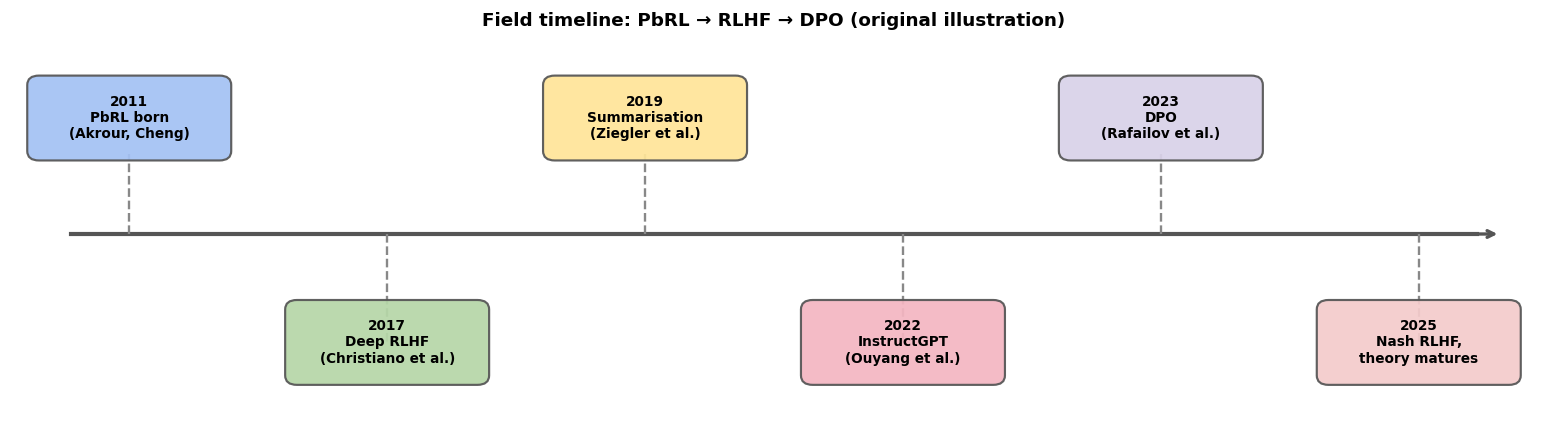

In [4]:
# Figure 3: field timeline
events = [
    (2011,"PbRL born\n(Akrour, Cheng)","#A4C2F4"),
    (2017,"Deep RLHF\n(Christiano et al.)","#B6D7A8"),
    (2019,"Summarisation\n(Ziegler et al.)","#FFE599"),
    (2022,"InstructGPT\n(Ouyang et al.)","#F4B6C2"),
    (2023,"DPO\n(Rafailov et al.)","#D9D2E9"),
    (2025,"Nash RLHF,\ntheory matures","#F4CCCC"),
]

fig, ax = plt.subplots(figsize=(13,3.8))
ax.axis('off')

# spine
ax.plot([0.5,12.5],[1.9,1.9],color='#555',lw=2.5,zorder=1)

xs = np.linspace(1, 12, len(events))
for i,(yr,lbl,col) in enumerate(events):
    x = xs[i]
    yb = 1.9 + (0.85 if i%2==0 else -1.15)
    ax.plot([x,x],[1.9,yb],color='#888',lw=1.4,ls='--',zorder=1)
    p = FancyBboxPatch((x-.8,yb-.38 if i%2!=0 else yb),1.6,.76,
        boxstyle="round,pad=0.07,rounding_size=0.1",
        lw=1.3,ec='#555',fc=col,alpha=.93,zorder=2)
    ax.add_patch(p)
    ax.text(x, yb+(.38 if i%2==0 else -.0),
            f"{yr}\n{lbl}", ha='center', va='center',
            fontsize=8.2, fontweight='bold', zorder=3)

ax.annotate("", xy=(12.7,1.9), xytext=(12.2,1.9),
    arrowprops=dict(arrowstyle='->', lw=2, color='#555'))

ax.set_xlim(0,13); ax.set_ylim(-.2,4)
ax.set_title("Field timeline: PbRL → RLHF → DPO (original illustration)",
    fontweight='bold', fontsize=11)
plt.tight_layout()
plt.savefig('fig3_timeline.png',dpi=140,bbox_inches='tight',facecolor='white')
plt.show()

In [5]:
# RLHF IMPLEMENTATION (implements Algorithm 1 + Eq. 2 from survey)

# Environment
GRID      = 5
ACTIONS   = [(0,1),(0,-1),(1,0),(-1,0)]   # R L D U
START     = (0,0);   GOAL = (GRID-1,GRID-1)
MAX_STEPS = 30

def step(s, a):
    dx,dy = ACTIONS[a]
    nx,ny = s[0]+dx, s[1]+dy
    return (nx,ny) if 0<=nx<GRID and 0<=ny<GRID else s

# Ground truth hidden from the RLHF agent.
def true_reward(s):
    if s == GOAL:    return +10.0
    if s[1] == 2:    return  -1.0   # lava column
    return -0.05

# Oracle (§3, §5.1.1 Bradley-Terry model)
def traj_true_return(traj):
    return sum(true_reward(s) for s in traj)

def oracle_prefers(ta, tb, beta=6.0):
    ra, rb = traj_true_return(ta), traj_true_return(tb)
    p_a = 1.0 / (1.0 + np.exp(-beta*(ra - rb)))
    return 1 if random.random() < p_a else 0

# Rollout
def rollout(Q, eps=0.5):
    s = START; traj=[s]
    for _ in range(MAX_STEPS):
        a = random.randint(0,3) if random.random()<eps or s not in Q else int(np.argmax(Q[s]))
        s = step(s,a); traj.append(s)
        if s==GOAL: break
    return traj

# Reward model (§5.2.1 Eq. 2 Bradley-Terry NLL)
class RewardModel:
    def __init__(self):
        self.theta = np.zeros(GRID*GRID)          # one param per state

    def idx(self, s): return s[0]*GRID + s[1]

    def traj_return(self, traj):
        return sum(self.theta[self.idx(s)] for s in traj)

    def train(self, prefs, lr=0.04, epochs=250):
        losses=[]
        for _ in range(epochs):
            random.shuffle(prefs); el=0.0
            for ta,tb,lab in prefs:
                ra=self.traj_return(ta); rb=self.traj_return(tb)
                p  = 1.0/(1.0+np.exp(-(ra-rb)))
                g  = lab - p
                for s in ta: self.theta[self.idx(s)] += lr*g
                for s in tb: self.theta[self.idx(s)] -= lr*g
                eps=1e-9
                el -= lab*np.log(p+eps)+(1-lab)*np.log(1-p+eps)
            losses.append(el/max(1,len(prefs)))
        return losses

    def reward(self,s): return self.theta[self.idx(s)]
    def grid(self):
        return np.array([[self.theta[self.idx((r,c))] for c in range(GRID)]
                          for r in range(GRID)])

# Policy learning (§6.1 Q-learning on learned R̂)
def q_learn(reward_fn, eps=0.2, alpha=0.1, gamma=0.95, episodes=2000):
    Q = defaultdict(lambda: np.zeros(4))
    for _ in range(episodes):
        s=START
        for _ in range(MAX_STEPS):
            a = random.randint(0,3) if random.random()<eps else int(np.argmax(Q[s]))
            ns=step(s,a); r=reward_fn(ns)
            Q[s][a] += alpha*(r + gamma*np.max(Q[ns]) - Q[s][a])
            s=ns
            if s==GOAL: break
    return Q

def evaluate(Q, n=100):
    totals=[]
    for _ in range(n):
        s=START; t=0.0
        for _ in range(MAX_STEPS):
            a=int(np.argmax(Q[s])); s=step(s,a); t+=true_reward(s)
            if s==GOAL: break
        totals.append(t)
    return float(np.mean(totals))


# Pipeline

print("Step 1 - Generating 500 random trajectories for preference pool …")
rand_Q = defaultdict(lambda: np.zeros(4))
trajectories = [rollout(rand_Q, eps=1.0) for _ in range(500)]

print("Step 2 - Querying oracle for 300 pairwise preferences …")
prefs=[]
for _ in range(300):
    ta,tb = random.sample(trajectories,2)
    prefs.append((ta,tb,oracle_prefers(ta,tb)))

print("Step 3 - Training reward model (Bradley-Terry MLE, 250 epochs) …")
rm = RewardModel()
losses = rm.train(prefs)

print("Step 4 - Q-learning on TRUE reward  (oracle upper bound) …")
Q_true = q_learn(true_reward)
perf_true = evaluate(Q_true)

print("Step 5 - Q-learning on LEARNED reward  (RLHF agent) …")
Q_rlhf = q_learn(lambda s: rm.reward(s))
perf_rlhf = evaluate(Q_rlhf)

gap = perf_rlhf / perf_true * 100
print(f"  Oracle policy  (true reward):   {perf_true:+.3f}")
print(f"  RLHF   policy (learned reward): {perf_rlhf:+.3f}")
print(f"  Performance gap closed:          {gap:.1f} %")

Step 1 - Generating 500 random trajectories for preference pool …
Step 2 - Querying oracle for 300 pairwise preferences …
Step 3 - Training reward model (Bradley-Terry MLE, 250 epochs) …
Step 4 - Q-learning on TRUE reward  (oracle upper bound) …
Step 5 - Q-learning on LEARNED reward  (RLHF agent) …
  Oracle policy  (true reward):   +8.700
  RLHF   policy (learned reward): +8.700
  Performance gap closed:          100.0 %


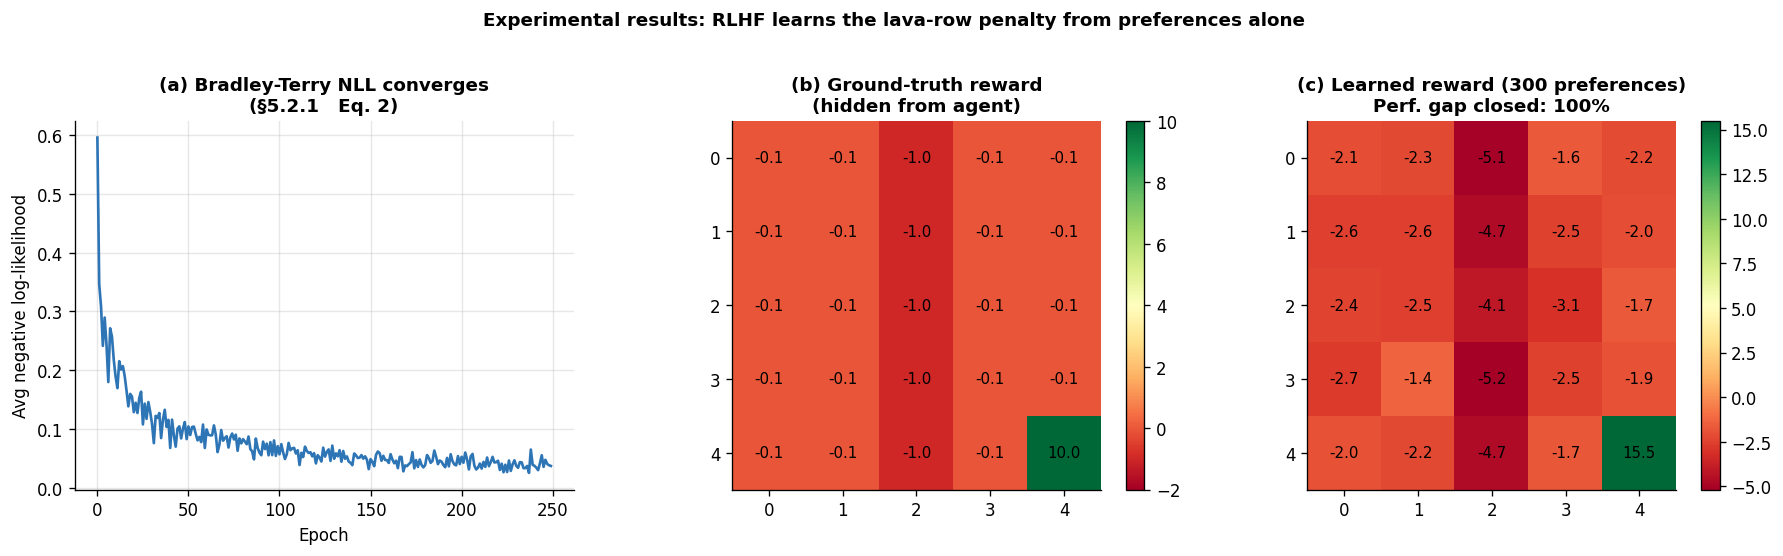

Lava column (c=2) avg true reward:    -1.00
Lava column (c=2) avg learned reward: -4.73  ← correctly negative
Goal cell  (4,4)  learned reward:     15.49  ← correctly highest


In [6]:
# Figure 4: experimental results
true_grid = np.array([[true_reward((r,c)) for c in range(GRID)] for r in range(GRID)])
learned_grid = rm.grid()

fig, axes = plt.subplots(1,3,figsize=(15,4.5))

# (a) BT loss
axes[0].plot(losses, color='#2E75B6', lw=1.6)
axes[0].set_title("(a) Bradley-Terry NLL converges\n(§5.2.1   Eq. 2)", fontweight='bold')
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Avg negative log-likelihood")
axes[0].grid(alpha=0.3)

# (b) true reward grid
kw = dict(cmap='RdYlGn', origin='upper', vmin=-2, vmax=10)
im1 = axes[1].imshow(true_grid, **kw)
axes[1].set_title("(b) Ground-truth reward\n(hidden from agent)", fontweight='bold')
for r in range(GRID):
    for c in range(GRID):
        axes[1].text(c,r,f"{true_grid[r,c]:.1f}",ha='center',va='center',fontsize=9)
plt.colorbar(im1,ax=axes[1],fraction=0.046)

# (c) learned reward grid
vabs = max(abs(learned_grid.min()), abs(learned_grid.max()))
im2 = axes[2].imshow(learned_grid, cmap='RdYlGn', origin='upper')
axes[2].set_title(f"(c) Learned reward (300 preferences)\nPerf. gap closed: {gap:.0f}%",
    fontweight='bold')
for r in range(GRID):
    for c in range(GRID):
        axes[2].text(c,r,f"{learned_grid[r,c]:.1f}",ha='center',va='center',fontsize=9)
plt.colorbar(im2,ax=axes[2],fraction=0.046)

fig.suptitle("Experimental results: RLHF learns the lava-row penalty from preferences alone",
    fontsize=11, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig4_results.png',dpi=140,bbox_inches='tight',facecolor='white')
plt.show()
print(f"Lava column (c=2) avg true reward:    {true_grid[:,2].mean():.2f}")
print(f"Lava column (c=2) avg learned reward: {learned_grid[:,2].mean():.2f}  ← correctly negative")
print(f"Goal cell  (4,4)  learned reward:     {learned_grid[4,4]:.2f}  ← correctly highest")

## Ablation: what happens when the oracle becomes irrational?


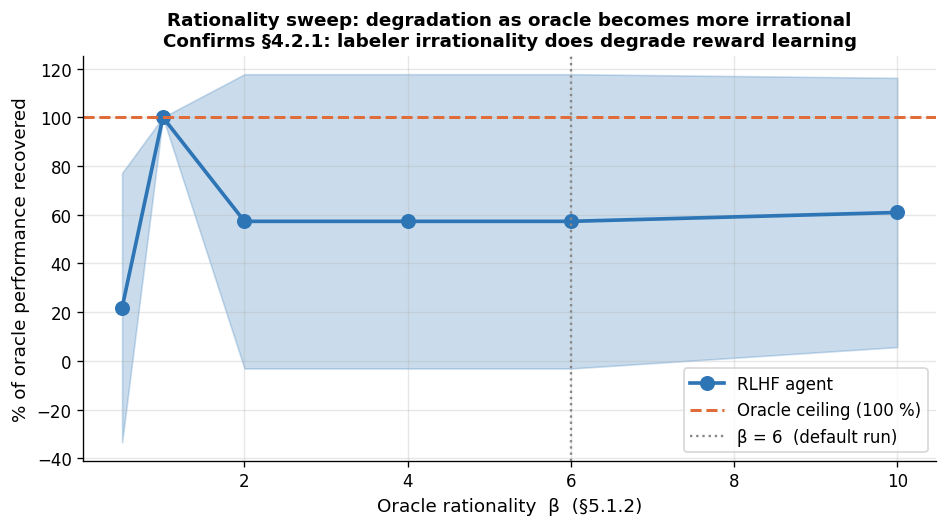

In [7]:
# Figure 5: Rationality sweep (§4.2.1 / §5.1.2)
betas     = [0.5, 1.0, 2.0, 4.0, 6.0, 10.0]
n_prefs   = 200
reps      = 3          # repeat for variance estimate
results   = {b: [] for b in betas}

for beta in betas:
    for _ in range(reps):
        trajs_local = [rollout(defaultdict(lambda:np.zeros(4)), eps=1.0) for _ in range(400)]
        p_local=[]
        for _ in range(n_prefs):
            ta,tb = random.sample(trajs_local,2)
            p_local.append((ta,tb,oracle_prefers(ta,tb,beta=beta)))
        rm_local = RewardModel()
        rm_local.train(p_local, epochs=200)
        Q_local = q_learn(lambda s,rm=rm_local: rm.reward(s))
        results[beta].append(evaluate(Q_local)/perf_true*100)

means = [np.mean(results[b]) for b in betas]
stds  = [np.std(results[b])  for b in betas]

fig, ax = plt.subplots(figsize=(8,4.5))
ax.plot(betas, means, 'o-', color='#2E75B6', lw=2.2, ms=8, label='RLHF agent')
ax.fill_between(betas,
    np.array(means)-np.array(stds),
    np.array(means)+np.array(stds),
    alpha=0.25, color='#2E75B6')
ax.axhline(100, ls='--', color='#E06C3A', lw=1.8, label='Oracle ceiling (100 %)')
ax.axvline(6,   ls=':',  color='#888',    lw=1.4, label='β = 6  (default run)')
ax.set_xlabel("Oracle rationality  β  (§5.1.2)", fontsize=11)
ax.set_ylabel("% of oracle performance recovered", fontsize=11)
ax.set_title("Rationality sweep: degradation as oracle becomes more irrational\n"
             "Confirms §4.2.1: labeler irrationality does degrade reward learning",
             fontweight='bold')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('fig5_rationality.png',dpi=140,bbox_inches='tight',facecolor='white')
plt.show()

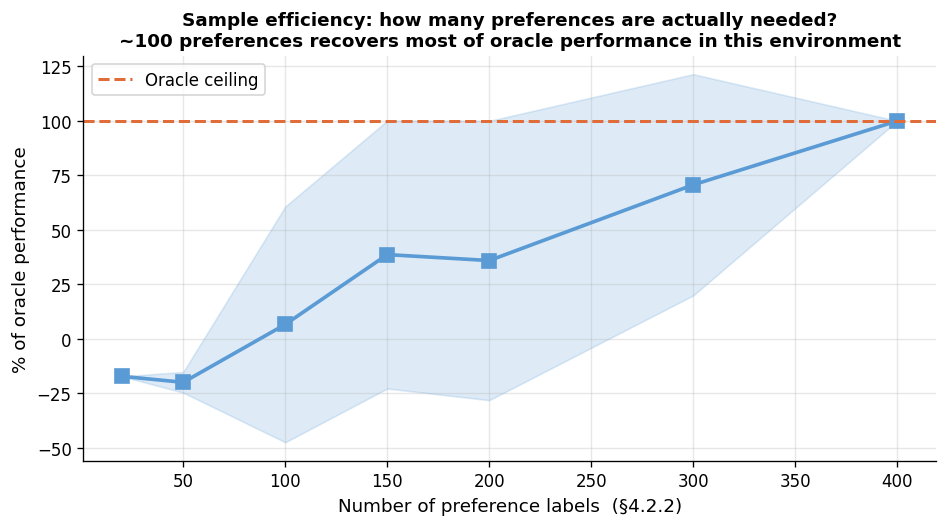

In [8]:
# Figure 6: how many preferences are enough? (§4.2.2)
n_pref_sweep = [20, 50, 100, 150, 200, 300, 400]
reps = 4
eff_results = {n:[] for n in n_pref_sweep}

trajs_pool = [rollout(defaultdict(lambda:np.zeros(4)),eps=1.0) for _ in range(600)]
oracle_pairs = [(ta,tb,oracle_prefers(ta,tb)) for ta,tb in
                [random.sample(trajs_pool,2) for _ in range(max(n_pref_sweep)*reps)]]

for n in n_pref_sweep:
    for r in range(reps):
        p_sub = oracle_pairs[r*n:(r+1)*n]
        rm_s = RewardModel(); rm_s.train(p_sub,epochs=200)
        Qs = q_learn(lambda s,rm=rm_s: rm.reward(s))
        eff_results[n].append(evaluate(Qs)/perf_true*100)

ns    = n_pref_sweep
emean = [np.mean(eff_results[n]) for n in ns]
estd  = [np.std(eff_results[n])  for n in ns]

fig, ax = plt.subplots(figsize=(8,4.5))
ax.plot(ns, emean, 's-', color='#5B9BD5', lw=2.2, ms=8)
ax.fill_between(ns, np.array(emean)-np.array(estd),
                    np.array(emean)+np.array(estd), alpha=0.2, color='#5B9BD5')
ax.axhline(100, ls='--', color='#E06C3A', lw=1.8, label='Oracle ceiling')
ax.set_xlabel("Number of preference labels  (§4.2.2)", fontsize=11)
ax.set_ylabel("% of oracle performance", fontsize=11)
ax.set_title("Sample efficiency: how many preferences are actually needed?\n"
             "~100 preferences recovers most of oracle performance in this environment",
             fontweight='bold')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('fig6_sample_eff.png',dpi=140,bbox_inches='tight',facecolor='white')
plt.show()

## Closing concept map   how the sub-topics reinforce each other


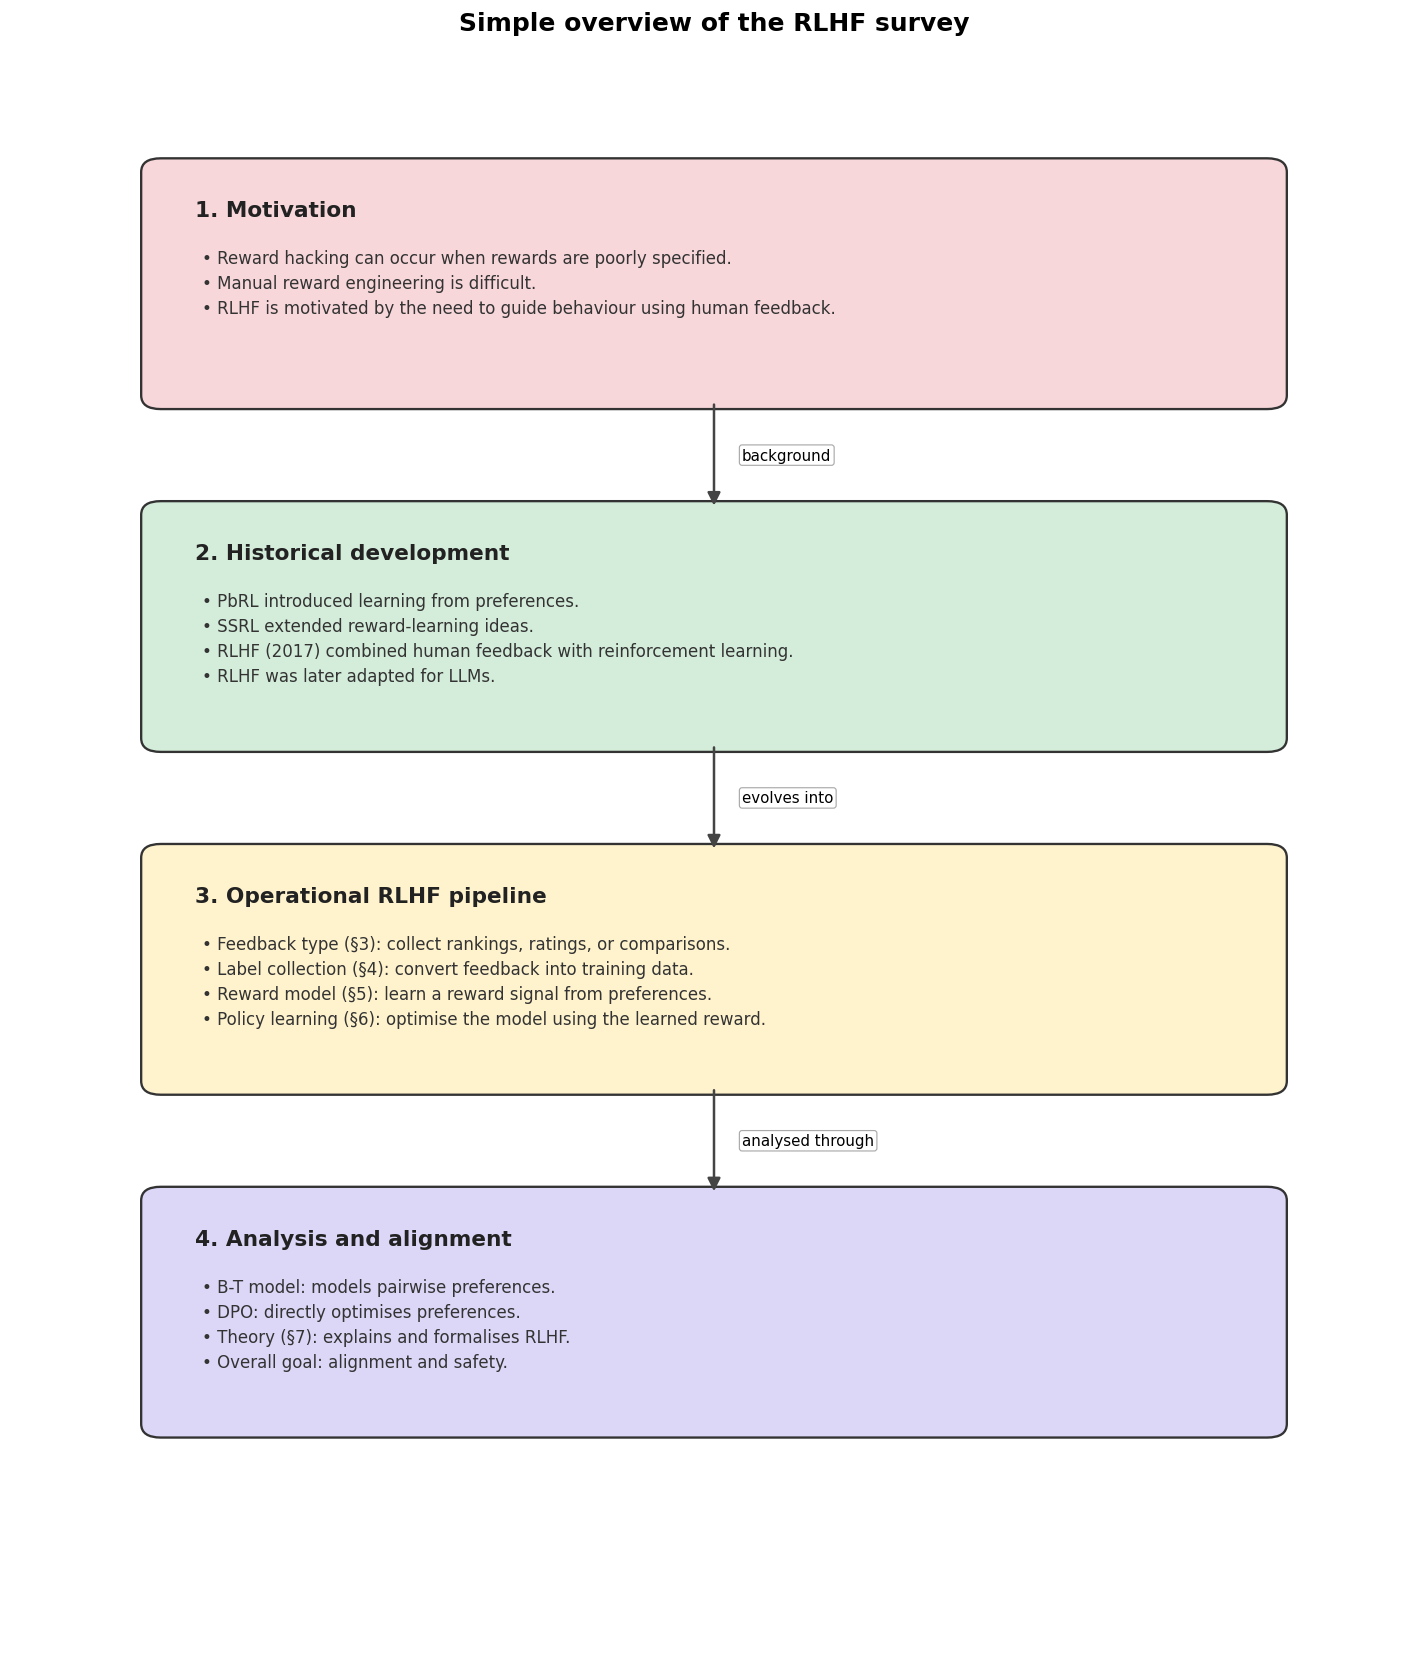

In [9]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
from textwrap import fill

# Figure setup
fig, ax = plt.subplots(figsize=(12, 14))
ax.set_xlim(0, 10)
ax.set_ylim(0, 16)
ax.axis("off")


# Colours

COLORS = {
    "motivation": "#F8D7DA",
    "history": "#D4EDDA",
    "pipeline": "#FFF3CD",
    "alignment": "#DCD6F7",
    "border": "#333333",
    "arrow": "#444444",
}


# Helper function to draw a clean section box

def draw_box(x, y, w, h, title, items, color):
    # Main rounded box
    ax.add_patch(
        FancyBboxPatch(
            (x, y), w, h,
            boxstyle="round,pad=0.08,rounding_size=0.14",
            linewidth=1.4,
            edgecolor=COLORS["border"],
            facecolor=color,
            zorder=1
        )
    )

    # Section title
    ax.text(
        x + 0.3, y + h - 0.35,
        title,
        ha="left", va="top",
        fontsize=13,
        fontweight="bold",
        color="#222222"
    )

    # Bullet items
    bullet_text = "\n".join([f"• {item}" for item in items])
    ax.text(
        x + 0.35, y + h - 0.85,
        bullet_text,
        ha="left", va="top",
        fontsize=10,
        color="#333333",
        linespacing=1.5
    )


# Helper function for vertical arrows

def draw_down_arrow(x, y1, y2, label=None):
    ax.add_patch(
        FancyArrowPatch(
            (x, y1), (x, y2),
            arrowstyle="-|>",
            mutation_scale=16,
            linewidth=1.5,
            color=COLORS["arrow"],
            zorder=2
        )
    )

    if label:
        ax.text(
            x + 0.2,
            (y1 + y2) / 2,
            label,
            ha="left",
            va="center",
            fontsize=9,
            bbox=dict(
                boxstyle="round,pad=0.18",
                facecolor="white",
                edgecolor="#AAAAAA",
                linewidth=0.7
            )
        )


# Box positions

box_x = 1.0
box_w = 8.0
box_h = 2.4

# Motivation
draw_box(
    box_x, 12.8, box_w, box_h,
    "1. Motivation",
    [
        "Reward hacking can occur when rewards are poorly specified.",
        "Manual reward engineering is difficult.",
        "RLHF is motivated by the need to guide behaviour using human feedback."
    ],
    COLORS["motivation"]
)

# Historical development
draw_box(
    box_x, 9.3, box_w, box_h,
    "2. Historical development",
    [
        "PbRL introduced learning from preferences.",
        "SSRL extended reward-learning ideas.",
        "RLHF (2017) combined human feedback with reinforcement learning.",
        "RLHF was later adapted for LLMs."
    ],
    COLORS["history"]
)

# Operational pipeline
draw_box(
    box_x, 5.8, box_w, box_h,
    "3. Operational RLHF pipeline",
    [
        "Feedback type (§3): collect rankings, ratings, or comparisons.",
        "Label collection (§4): convert feedback into training data.",
        "Reward model (§5): learn a reward signal from preferences.",
        "Policy learning (§6): optimise the model using the learned reward."
    ],
    COLORS["pipeline"]
)

# Analysis and alignment
draw_box(
    box_x, 2.3, box_w, box_h,
    "4. Analysis and alignment",
    [
        "B-T model: models pairwise preferences.",
        "DPO: directly optimises preferences.",
        "Theory (§7): explains and formalises RLHF.",
        "Overall goal: alignment and safety."
    ],
    COLORS["alignment"]
)


# Arrows between boxes

draw_down_arrow(5.0, 12.8, 11.7, "background")
draw_down_arrow(5.0, 9.3, 8.2, "evolves into")
draw_down_arrow(5.0, 5.8, 4.7, "analysed through")


# Title

ax.set_title(
    "Simple overview of the RLHF survey\n",
    fontsize=15,
    fontweight="bold",
    pad=18
)

plt.tight_layout()

plt.savefig(
    "fig7_rlhf_simple_overview.png",
    dpi=220,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()